![tracker](https://us-central1-vertex-ai-mlops-369716.cloudfunctions.net/pixel-tracking?path=statmike%2Fvertex-ai-mlops%2Fdata%2Bai%2Ftabular-data%2Fbq-reads&file=bq-reads.ipynb)
<!--- header table --->
<table>
<tr>
  <td style="text-align: center">
    <a href="https://github.com/statmike/vertex-ai-mlops/blob/main/data%2Bai/tabular-data/bq-reads/bq-reads.ipynb">
      <img width="32px" src="https://www.svgrepo.com/download/217753/github.svg" alt="GitHub logo">
      <br>View on<br>GitHub
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://colab.research.google.com/github/statmike/vertex-ai-mlops/blob/main/data%2Bai/tabular-data/bq-reads/bq-reads.ipynb">
      <img width="32px" src="https://www.gstatic.com/pantheon/images/bigquery/welcome_page/colab-logo.svg" alt="Google Colaboratory logo">
      <br>Run in<br>Colab
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/colab/import/https%3A%2F%2Fraw.githubusercontent.com%2Fstatmike%2Fvertex-ai-mlops%2Fmain%2Fdata%252Bai%2Ftabular-data%2Fbq-reads%2Fbq-reads.ipynb">
      <img width="32px" src="https://lh3.googleusercontent.com/JmcxdQi-qOpctIvWKgPtrzZdJJK-J3sWE1RsfjZNwshCFgE_9fULcNpuXYTilIR2hjwN" alt="Google Cloud Colab Enterprise logo">
      <br>Run in<br>Colab Enterprise
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/workbench/deploy-notebook?download_url=https://raw.githubusercontent.com/statmike/vertex-ai-mlops/main/data%252Bai/tabular-data/bq-reads/bq-reads.ipynb">
      <img width="32px" src="https://www.gstatic.com/images/branding/gcpiconscolors/vertexai/v1/32px.svg" alt="Vertex AI logo">
      <br>Open in<br>Vertex AI Workbench
    </a>
  </td>
</tr>
</table><br/><br/>

# Reading BigQuery Tables into Pandas for ML

When building ML models in Python, data often lives in BigQuery while the ML framework (scikit-learn, PyTorch, TensorFlow, JAX) needs it as a **pandas DataFrame**. The question is: *how do you get the data out efficiently?*

The obvious approach — `client.query("SELECT * FROM table").to_dataframe()` — works, but it **runs a query**. With on-demand pricing, that means paying for bytes scanned ($6.25/TB). With editions/slots pricing, it consumes slot-milliseconds. If you just want to read a table's contents, that query cost is unnecessary.

**BigQuery's Storage Read API** reads directly from a table's storage layer — no query engine, no query cost. And with parallel streams, it's often faster too.

This notebook compares **five approaches** by cost and speed, then dives deep into multi-threaded storage reads.

**Positioning:**
- **BigFrames** = the easy path (storage reads managed for you)
- **Storage Read API** = maximum control (parallel streams, thread tuning)
- **pandas-gbq with `use_bqstorage_api`** = surprisingly fast with zero threading code

---
## Environment

In [1]:
PROJECT_ID = 'statmike-mlops-349915'  # <-- Replace with your project ID

### Install Packages

In [2]:
import subprocess, sys, shutil

def install(*packages):
    """Install packages using uv (fast) with pip fallback."""
    uv = shutil.which('uv')
    if uv:
        subprocess.check_call([uv, 'pip', 'install', '-q', '--python', sys.executable, *packages])
    else:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', *packages])

install(
    'google-cloud-bigquery',
    'google-cloud-bigquery-storage',
    'bigframes',
    'pandas-gbq',
    'db-dtypes',
    'pyarrow',
    'tqdm',
    'matplotlib',
)

### Restart Kernel (If Installs Occurred)

If packages were newly installed above, restart the kernel and continue from the next cell.

In [3]:
# Uncomment and run if packages were newly installed:
# import IPython; IPython.Application.instance().kernel.do_shutdown(True)

---
## Setup

### Imports

In [4]:
import time
import gc
import os
import concurrent.futures

import pandas as pd
import pandas_gbq
import pyarrow
from google.cloud import bigquery
from google.cloud import bigquery_storage
import bigframes.pandas as bpd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

/usr/local/google/home/statmike/Git/vertex-ai-mlops/data+ai/tabular-data/bq-reads/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Authenticate

In [5]:
# Colab only — other environments use Application Default Credentials
try:
    from google.colab import auth
    auth.authenticate_user()
except ImportError:
    pass

### Create Clients

In [6]:
bq = bigquery.Client(project=PROJECT_ID)
bqstorage = bigquery_storage.BigQueryReadClient()
bpd.options.bigquery.project = PROJECT_ID

print(f'Project: {PROJECT_ID}')

Project: statmike-mlops-349915


---
## The Demo Table

We use the [Chicago Taxi Trips](https://console.cloud.google.com/marketplace/product/city-of-chicago-public-data/chicago-taxi-trips) public dataset — a single large table with many columns including numeric features useful for ML (fares, distances, coordinates, timestamps).

In [7]:
# Demo table — large, many columns, good numeric features for ML
BQ_PROJECT = 'bigquery-public-data'
BQ_DATASET = 'chicago_taxi_trips'
BQ_TABLE = 'taxi_trips'
TABLE_REF = f'{BQ_PROJECT}.{BQ_DATASET}.{BQ_TABLE}'

# Discover table metadata
table_info = bq.get_table(TABLE_REF)
print(f'Table:   {TABLE_REF}')
print(f'Rows:    {table_info.num_rows:,}')
print(f'Size:    {table_info.num_bytes / 1e9:.1f} GB')
print(f'Columns: {len(table_info.schema)}')
print()
for field in table_info.schema:
    print(f'  {field.name:<35s} {field.field_type}')

Table:   bigquery-public-data.chicago_taxi_trips.taxi_trips
Rows:    211,655,459
Size:    82.4 GB
Columns: 23

  unique_key                          STRING
  taxi_id                             STRING
  trip_start_timestamp                TIMESTAMP
  trip_end_timestamp                  TIMESTAMP
  trip_seconds                        INTEGER
  trip_miles                          FLOAT
  pickup_census_tract                 INTEGER
  dropoff_census_tract                INTEGER
  pickup_community_area               INTEGER
  dropoff_community_area              INTEGER
  fare                                FLOAT
  tips                                FLOAT
  tolls                               FLOAT
  extras                              FLOAT
  trip_total                          FLOAT
  payment_type                        STRING
  company                             STRING
  pickup_latitude                     FLOAT
  pickup_longitude                    FLOAT
  pickup_location              

In [8]:
# Preview a few rows
bq.query(f'SELECT * FROM `{TABLE_REF}` LIMIT 5').to_dataframe()

,unique_key,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,extras,trip_total,payment_type,company,pickup_latitude,pickup_longitude,pickup_location,dropoff_latitude,dropoff_longitude,dropoff_location
0,6798ad72f7262aa9e9563bba49b4845bef1778bf,07f2bd961ac4c9e067abf0b0e4074aec9d6507f7d0373a...,2018-08-02 15:00:00+00:00,2018-08-02 15:15:00+00:00,982,1.22,<NA>,<NA>,<NA>,<NA>,...,0.0,11.00,Credit Card,Chicago Carriage Cab Corp,NaN,NaN,None,NaN,NaN,None
1,ac8627ceecf2665a10f40800228ef04919a1c010,07f2bd961ac4c9e067abf0b0e4074aec9d6507f7d0373a...,2018-08-02 15:15:00+00:00,2018-08-02 15:30:00+00:00,284,0.89,<NA>,<NA>,<NA>,<NA>,...,0.0,10.00,Credit Card,Chicago Carriage Cab Corp,NaN,NaN,None,NaN,NaN,None
2,c51e5252661a853a94eb611a5dd48b1c5241fb4d,07f2bd961ac4c9e067abf0b0e4074aec9d6507f7d0373a...,2018-08-02 15:30:00+00:00,2018-08-02 15:45:00+00:00,909,3.07,<NA>,<NA>,<NA>,<NA>,...,0.0,14.00,Credit Card,Chicago Carriage Cab Corp,NaN,NaN,None,NaN,NaN,None
3,69c1a2bcbe0f5aae3f9d63c4c46e4b1137593eb8,07f2bd961ac4c9e067abf0b0e4074aec9d6507f7d0373a...,2018-08-02 16:15:00+00:00,2018-08-02 16:30:00+00:00,1324,1.67,<NA>,<NA>,<NA>,<NA>,...,0.0,14.25,Credit Card,Chicago Carriage Cab Corp,NaN,NaN,None,NaN,NaN,None
4,da3bc56ef1fcab45512555d39d1953377f92cd0f,07f2bd961ac4c9e067abf0b0e4074aec9d6507f7d0373a...,2018-08-02 16:45:00+00:00,2018-08-02 16:45:00+00:00,229,0.78,<NA>,<NA>,<NA>,<NA>,...,0.0,5.75,Credit Card,Chicago Carriage Cab Corp,NaN,NaN,None,NaN,NaN,None


### Columns for ML

We select numeric columns relevant for ML. This subset is used for **column pruning** — reading only what we need instead of all 23 columns.

In [9]:
# Numeric columns for ML — used for column pruning demos
NUMERIC_COLUMNS = [
    'trip_seconds', 'trip_miles',
    'fare', 'tips', 'tolls', 'extras', 'trip_total',
    'pickup_latitude', 'pickup_longitude',
    'dropoff_latitude', 'dropoff_longitude',
]

print(f'Selected {len(NUMERIC_COLUMNS)} numeric columns for ML')

Selected 11 numeric columns for ML


### Benchmark Filter

This table has 200M+ rows and is 80+ GB. Reading all of it into local pandas memory would crash most machines. We define a **row filter** to limit benchmark reads to a manageable subset — enough rows for meaningful timing (millions) but safe for memory.

The filter is used consistently across all approaches for fair comparison.

In [10]:
# Discover the date range to pick a valid filter
date_range = bq.query(f"""
    SELECT
        FORMAT_TIMESTAMP('%Y-%m-%d', MIN(trip_start_timestamp)) as min_date,
        FORMAT_TIMESTAMP('%Y-%m-%d', MAX(trip_start_timestamp)) as max_date
    FROM `{TABLE_REF}`
""").to_dataframe()
print(f'Data range: {date_range["min_date"].iloc[0]} to {date_range["max_date"].iloc[0]}')

Data range: 2013-01-01 to 2023-12-31


In [11]:
# Row filter: 3 months of data — gives millions of rows without exhausting memory
ROW_FILTER = "trip_start_timestamp >= '2020-01-01' AND trip_start_timestamp < '2020-04-01'"

# Verify row count
count_df = bq.query(
    f"SELECT COUNT(*) as n FROM `{TABLE_REF}` WHERE {ROW_FILTER}"
).to_dataframe()
EXPECTED_ROWS = count_df['n'].iloc[0]

# Estimate memory: each numeric column is 8 bytes (float64)
est_memory_gb = EXPECTED_ROWS * len(NUMERIC_COLUMNS) * 8 / 1e9

print(f'Row filter:      {ROW_FILTER}')
print(f'Expected rows:   {EXPECTED_ROWS:,}')
print(f'Est. memory:     {est_memory_gb:.2f} GB ({len(NUMERIC_COLUMNS)} float64 columns)')
print()
if EXPECTED_ROWS == 0:
    print('WARNING: Filter returned 0 rows. Adjust the date range above.')
elif est_memory_gb > 4:
    print('WARNING: Estimated memory > 4 GB. Consider narrowing the date range.')
else:
    print('Looks good — safe for local memory.')

Row filter:      trip_start_timestamp >= '2020-01-01' AND trip_start_timestamp < '2020-04-01'
Expected rows:   2,752,875
Est. memory:     0.24 GB (11 float64 columns)

Looks good — safe for local memory.


In [12]:
# The SQL query used by query-based approaches
BENCHMARK_QUERY = f"""
SELECT {', '.join(NUMERIC_COLUMNS)}
FROM `{TABLE_REF}`
WHERE {ROW_FILTER}
"""
print(BENCHMARK_QUERY)


SELECT trip_seconds, trip_miles, fare, tips, tolls, extras, trip_total, pickup_latitude, pickup_longitude, dropoff_latitude, dropoff_longitude
FROM `bigquery-public-data.chicago_taxi_trips.taxi_trips`
WHERE trip_start_timestamp >= '2020-01-01' AND trip_start_timestamp < '2020-04-01'



---
## Why How You Read Matters

Two axes matter when reading BigQuery data into pandas:

1. **Cost** — Does the read run a query? On-demand pricing charges $6.25/TB scanned. Storage reads are free up to **300 TiB/month per billing account**, then $1.10/TiB. For context, our filtered benchmark reads ~19 GB — you'd need ~15,000 runs/month to exceed the free tier. But running the same *query* 100 times during ML development at $0.12/run = $12 wasted.
2. **Speed** — Can the read use parallel streams? Sequential reads are bottlenecked by single-connection throughput.

The table below summarizes five approaches. We'll demonstrate each one, then compare them at the end.

### Approaches at a Glance

| Approach | Runs a Query? | Cost | Parallel? | Column Pruning | Row Filtering | Thread Control? |
|---|---|---|---|---|---|---|
| `client.query()` | Yes | Bytes scanned | Auto (Storage API download) | SQL `SELECT` | SQL `WHERE` | No |
| `client.list_rows()` | No | Storage reads* | No (sequential) | `selected_fields` | No | No |
| `pandas_gbq.read_gbq()` | Yes | Bytes scanned | Auto with `use_bqstorage_api` | SQL `SELECT` | SQL `WHERE` | No |
| BigFrames `read_gbq_table()` | No | Storage reads* | Yes (managed) | `columns` | `filters` | No |
| Storage Read API | No | Storage reads* | Yes (multi-stream) | `selected_fields` | `row_restriction` | Yes (`max_stream_count` + `ThreadPoolExecutor`) |

*\*Storage reads: free up to 300 TiB/month per billing account, then $1.10/TiB.*

> **Key insight**: `client.query().to_dataframe()` automatically uses the Storage Read API for downloading results when `google-cloud-bigquery-storage` is installed. The query still costs money (bytes scanned), but the *download* is fast. This is why it's faster than `list_rows()` despite running a query.

In [13]:
# Collect timing results across approaches for comparison at the end
timings = []

---
## Approach 1: BigQuery Client — Query

The most common approach: run a SQL query and download results to a DataFrame.

```python
bq.query("SELECT ... FROM ...").to_dataframe()
```

This is flexible (any SQL) but **runs a query** — meaning cost. We disable the query cache with `use_query_cache=False` to measure actual scan performance. Without this, BigQuery caches results for 24 hours — repeat runs would show $0 cost and misleadingly fast times.

> **Note**: The `.to_dataframe()` call automatically uses the BigQuery Storage Read API for the download (when the package is installed). So the download step itself is fast and parallel — it's the *query execution* that costs money.

In [14]:
# Disable query cache to measure real scan performance
job_config = bigquery.QueryJobConfig(use_query_cache=False)

start = time.time()
job = bq.query(BENCHMARK_QUERY, job_config=job_config)
df_query = job.to_dataframe()
elapsed = time.time() - start

print(f'Rows:    {df_query.shape[0]:,}')
print(f'Columns: {df_query.shape[1]}')
print(f'Time:    {elapsed:.1f}s')

timings.append({'Approach': 'client.query()', 'Seconds': round(elapsed, 1), 'Rows': df_query.shape[0]})
df_query.head()

Rows:    2,752,875
Columns: 11
Time:    5.2s


,trip_seconds,trip_miles,fare,tips,tolls,extras,trip_total,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude
0,1740,0.00,13.00,0.00,0.0,0.0,13.00,NaN,NaN,41.761578,-87.572782
1,180,0.00,5.50,0.00,0.0,1.0,6.50,NaN,NaN,NaN,NaN
2,4140,24.30,61.75,0.00,0.0,0.0,61.75,NaN,NaN,NaN,NaN
3,447,0.77,6.25,1.55,0.0,1.0,9.30,NaN,NaN,NaN,NaN
4,2100,17.20,43.75,7.00,0.0,4.0,54.75,NaN,NaN,NaN,NaN


In [15]:
# Query cost: bytes processed and estimated price
bytes_processed = job.total_bytes_processed or 0
bytes_billed = job.total_bytes_billed or 0

print(f'Bytes processed: {bytes_processed / 1e9:.2f} GB')
print(f'Bytes billed:    {bytes_billed / 1e9:.2f} GB')
print(f'Cache hit:       {job.cache_hit}')

if bytes_billed > 0:
    cost_per_tb = 6.25  # on-demand pricing
    cost = (bytes_billed / 1e12) * cost_per_tb
    print(f'Estimated cost:  ${cost:.4f} (at ${cost_per_tb}/TB on-demand)')
    print(f'100 runs =       ${cost * 100:.2f}')
else:
    print('Estimated cost:  $0.00 (cached result)')

Bytes processed: 19.21 GB
Bytes billed:    19.21 GB
Cache hit:       False
Estimated cost:  $0.1201 (at $6.25/TB on-demand)
100 runs =       $12.01


In [16]:
del df_query, job
gc.collect()
print('Memory freed')

Memory freed


---
## Approach 2: BigQuery Client — `list_rows()`

`client.list_rows()` reads directly from BigQuery storage — **no query, no query cost**. It supports column pruning via `selected_fields` and row limiting via `max_results`.

The limitations:
- Reads are **sequential** (paginated, single stream) — slow for large tables
- **No row filtering** — rows come from the start of the table in storage order
- **No thread control** — always single-threaded
- Best for: quick previews or small tables where you want to avoid query cost

```python
bq.list_rows(table, selected_fields=[...], max_results=N).to_dataframe()
```

> Since `list_rows` can't filter, we use `max_results` to read a comparable number of rows.

In [17]:
# Read rows with column pruning — no query cost
selected_fields = [field for field in table_info.schema if field.name in NUMERIC_COLUMNS]

start = time.time()
df_list = bq.list_rows(
    TABLE_REF,
    selected_fields=selected_fields,
    max_results=EXPECTED_ROWS,
).to_dataframe()
elapsed = time.time() - start

print(f'Rows:    {df_list.shape[0]:,} (max_results={EXPECTED_ROWS:,})')
print(f'Columns: {df_list.shape[1]}')
print(f'Time:    {elapsed:.1f}s')
print(f'Cost:    $0 (storage read, no query)')

timings.append({'Approach': 'list_rows()', 'Seconds': round(elapsed, 1), 'Rows': df_list.shape[0]})
df_list.head()

Rows:    2,752,875 (max_results=2,752,875)
Columns: 11
Time:    163.4s
Cost:    $0 (storage read, no query)


,trip_seconds,trip_miles,fare,tips,tolls,extras,trip_total,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude
0,60,0.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,60,0.04,NaN,NaN,NaN,NaN,NaN,42.009623,-87.670167,41.986712,-87.663416
2,960,0.43,NaN,NaN,NaN,NaN,NaN,41.922686,-87.649489,41.965812,-87.655879
3,180,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,60,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
del df_list
gc.collect()
print('Memory freed')

Memory freed


---
## Approach 3: pandas-gbq

`pandas_gbq.read_gbq()` provides a pandas-native experience. By default it runs a query and downloads via REST — painfully slow. Toggle `use_bqstorage_api=True` to download via the Storage Read API instead.

```python
pandas_gbq.read_gbq(query, use_bqstorage_api=True)
```

**Limitations:**
- `use_bqstorage_api` **cannot be combined with `max_results`** — setting `max_results` silently disables the Storage API
- **No thread/stream control** — pandas-gbq delegates to the BigQuery client library, which manages parallelism automatically
- `pd.read_gbq()` is deprecated — use `pandas_gbq.read_gbq()` directly

> **Note**: The query result may hit BigQuery's cache from prior runs, making the query itself free. The timing below primarily measures download speed.

In [19]:
# Default mode — runs a query, downloads via REST API (slow)
start = time.time()
df_gbq = pandas_gbq.read_gbq(BENCHMARK_QUERY, project_id=PROJECT_ID)
elapsed = time.time() - start

print(f'Rows:    {df_gbq.shape[0]:,}')
print(f'Time:    {elapsed:.1f}s (default — REST download)')

timings.append({'Approach': 'pandas-gbq (default)', 'Seconds': round(elapsed, 1), 'Rows': df_gbq.shape[0]})

del df_gbq
_ = gc.collect()
print('Memory freed')

Downloading: 100%|██████████|
Rows:    2,752,875
Time:    200.6s (default — REST download)
Memory freed


In [20]:
# With Storage API — same query, but download uses Storage Read API (fast!)
start = time.time()
df_gbq_storage = pandas_gbq.read_gbq(
    BENCHMARK_QUERY, project_id=PROJECT_ID, use_bqstorage_api=True
)
elapsed = time.time() - start

print(f'Rows:    {df_gbq_storage.shape[0]:,}')
print(f'Time:    {elapsed:.1f}s (Storage API download)')
print()
print('The speed difference is entirely from how results are DOWNLOADED,')
print('not how the query runs. The Storage API uses parallel streams internally.')

timings.append({'Approach': 'pandas-gbq (storage)', 'Seconds': round(elapsed, 1), 'Rows': df_gbq_storage.shape[0]})

del df_gbq_storage
gc.collect()
print('Memory freed')

Downloading: 100%|██████████|
Rows:    2,752,875
Time:    3.8s (Storage API download)

The speed difference is entirely from how results are DOWNLOADED,
not how the query runs. The Storage API uses parallel streams internally.
Memory freed


---
## Approach 4: BigFrames

[BigFrames](https://cloud.google.com/bigquery/docs/bigquery-dataframes-introduction) provides a pandas-compatible API backed by BigQuery. `read_gbq_table()` creates a **lazy** reference — no data moves until you call `.to_pandas()`.

Under the hood, `.to_pandas()` downloads via the BigQuery Storage Read API — **no query cost** when reading tables directly. BigQuery manages parallelism internally; there's no exposed thread/stream control.

**Key features:**
- `columns` parameter prunes at storage layer
- `filters` parameter pushes row predicates to storage
- `to_pandas_batches()` for memory-safe chunked downloads
- **Partial ordering mode** (`ordering_mode="partial"`) enables better filter pushdown on partitioned/clustered tables

### Lazy Operations (Stay in BigQuery)

In [21]:
# read_gbq_table creates a lazy reference — no data downloaded yet
bf = bpd.read_gbq_table(TABLE_REF)

print(f'Type:    {type(bf)}')
print(f'Columns: {len(bf.columns)}')

# .head() downloads only a few rows for display
bf[NUMERIC_COLUMNS].head()

Type:    <class 'bigframes.dataframe.DataFrame'>
Columns: 23


,trip_seconds,trip_miles,fare,tips,tolls,extras,trip_total,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude
0,540,0.0,11.85,2.55,0.0,1.0,15.4,41.947792,-87.683835,41.874005,-87.663518
1,564,2.1,8.05,0.0,<NA>,0.0,8.05,41.892658,-87.652534,41.898332,-87.620763
2,500,1.1,6.75,2.0,0.0,0.0,9.25,41.899602,-87.633308,41.874005,-87.663518
3,360,0.9,6.0,1.0,0.0,0.0,7.5,41.893216,-87.637844,41.880994,-87.632746
4,420,1.1,7.0,1.25,0.0,1.0,9.75,41.879255,-87.642649,41.892508,-87.626215


### `read_gbq_table()` with Column + Row Filtering (No Query Cost)

This is the **zero-cost path**: column pruning and row filtering handled for you, using storage reads — no query cost. The `filters` parameter takes a list of `(column, operator, value)` tuples.

> **Session note**: BigFrames options like `ordering_mode` can only be changed before a session starts (or after calling `close_session()`). We close the previous session here to switch to `partial` ordering mode, which enables better filter pushdown on partitioned/clustered tables.

> **Performance note**: `read_gbq_table()` may be slightly slower than `read_gbq()` with SQL because it includes session startup overhead (after `close_session()`) and BigFrames' internal filter translation. The trade-off is **free reads** — no query cost per run. Over 100 iterations of ML development, avoiding $0.12/query adds up.

In [22]:
# Close the existing session so we can switch ordering mode
bpd.close_session()
bpd.options.bigquery.ordering_mode = 'partial'

# read_gbq_table with columns + filters — pure storage read, no query cost
start = time.time()
df_bf_table = bpd.read_gbq_table(
    TABLE_REF,
    columns=NUMERIC_COLUMNS,
    filters=[
        ("trip_start_timestamp", ">=", "2020-01-01"),
        ("trip_start_timestamp", "<", "2020-04-01"),
    ],
).to_pandas()
elapsed = time.time() - start

print(f'Rows:    {df_bf_table.shape[0]:,}')
print(f'Columns: {df_bf_table.shape[1]}')
print(f'Time:    {elapsed:.1f}s')
print(f'Cost:    $0 (storage read via read_gbq_table)')

timings.append({'Approach': 'BigFrames (table+filters)', 'Seconds': round(elapsed, 1), 'Rows': df_bf_table.shape[0]})

del df_bf_table
_ = gc.collect()
print('Memory freed')

Rows:    2,752,875
Columns: 11
Time:    4.0s
Cost:    $0 (storage read via read_gbq_table)
Memory freed


### `read_gbq()` with SQL Query (Faster, Has Cost)

For complex filtering (joins, aggregations, subqueries), or when you need maximum speed, use `read_gbq()` with a SQL query. This **runs a query** (has cost) but leverages BigQuery's query engine and may download faster than the storage-only path. Use this when speed per run matters more than per-run cost.

In [23]:
# read_gbq with SQL — runs a query (has cost), but useful for complex logic
start = time.time()
df_bf_query = bpd.read_gbq(BENCHMARK_QUERY).to_pandas()
elapsed = time.time() - start

print(f'Rows:    {df_bf_query.shape[0]:,}')
print(f'Columns: {df_bf_query.shape[1]}')
print(f'Time:    {elapsed:.1f}s')
print(f'Cost:    Query cost (bytes scanned)')

timings.append({'Approach': 'BigFrames (SQL query)', 'Seconds': round(elapsed, 1), 'Rows': df_bf_query.shape[0]})

del df_bf_query
_ = gc.collect()
print('Memory freed')

Rows:    2,752,875
Columns: 11
Time:    4.4s
Cost:    Query cost (bytes scanned)
Memory freed


### `to_pandas_batches()`

For downloads that might exceed local memory, `to_pandas_batches()` yields DataFrames in chunks. Process each batch and discard it before loading the next.

> BigFrames determines batch sizes internally — expect many small batches (often ~4K rows each). The iterator is **sequential** — you can't parallelize the download because batches are yielded one at a time. For parallel batch downloads, use the **Storage Read API** with `ThreadPoolExecutor` — each stream is effectively a "parallel batch" you control, with larger chunks and concurrent reads.

In [24]:
# Download in batches — useful when full result might not fit in memory
bf_filtered = bpd.read_gbq_table(
    TABLE_REF,
    columns=['trip_miles', 'fare', 'tips'],
    filters=[
        ("trip_start_timestamp", ">=", "2020-01-01"),
        ("trip_start_timestamp", "<", "2020-04-01"),
    ],
    use_cache=False,
)

batch_count = 0
total_rows = 0

for batch in bf_filtered.to_pandas_batches():
    batch_count += 1
    total_rows += len(batch)
    if batch_count <= 3:
        print(f'  Batch {batch_count}: {len(batch):,} rows')
    elif batch_count == 4:
        print(f'  ...')

print(f'\nTotal: {total_rows:,} rows in {batch_count} batches')
print(f'Avg batch size: {total_rows // max(batch_count, 1):,} rows')

del bf_filtered
_ = gc.collect()
print('Memory freed')

  Batch 1: 4,096 rows
  Batch 2: 4,096 rows
  Batch 3: 4,096 rows
  ...

Total: 2,752,875 rows in 684 batches
Avg batch size: 4,024 rows
Memory freed


---
## Approach 5: BigQuery Storage Read API

The [BigQuery Storage Read API](https://cloud.google.com/bigquery/docs/reference/storage) gives **maximum control**:

- **Column pruning**: `selected_fields` — only read the columns you need
- **Row filtering**: `row_restriction` — filter rows at the storage layer
- **Parallel streams**: `max_stream_count` — control how many streams BigQuery creates
- **Threading**: Read streams concurrently with `ThreadPoolExecutor` — you choose the thread count

This is the only approach that exposes thread/stream control.

### Creating a Read Session

In [25]:
# Helper to create a consistent read session
def create_session(max_streams=0, columns=None, row_filter=None):
    """Create a BigQuery Storage read session."""
    read_options = {}
    if columns:
        read_options['selected_fields'] = columns
    if row_filter:
        read_options['row_restriction'] = row_filter

    return bqstorage.create_read_session(
        request=dict(
            parent=f'projects/{PROJECT_ID}',
            read_session=dict(
                table=f'projects/{BQ_PROJECT}/datasets/{BQ_DATASET}/tables/{BQ_TABLE}',
                data_format=bigquery_storage.types.DataFormat.ARROW,
                read_options=read_options,
            ),
            max_stream_count=max_streams,
        )
    )

def read_stream(stream):
    """Read all rows from a single stream into a DataFrame."""
    return bqstorage.read_rows(name=stream.name).to_dataframe()

In [26]:
# Create benchmark session
session = create_session(columns=NUMERIC_COLUMNS, row_filter=ROW_FILTER)

print(f'Streams returned: {len(session.streams)}')
print(f'Data format:      ARROW')
print(f'Columns:          {len(NUMERIC_COLUMNS)}')
print(f'Row filter:       {ROW_FILTER}')

Streams returned: 212
Data format:      ARROW
Columns:          11
Row filter:       trip_start_timestamp >= '2020-01-01' AND trip_start_timestamp < '2020-04-01'


### Column Pruning

`selected_fields` reads only the columns you specify. Since BigQuery uses columnar storage, pruning dramatically reduces the data read from disk.

In [27]:
# Compare estimated bytes: all columns vs. pruned columns (both with row filter)
session_all = create_session(max_streams=1, row_filter=ROW_FILTER)
session_pruned = create_session(max_streams=1, columns=NUMERIC_COLUMNS, row_filter=ROW_FILTER)

bytes_all = session_all.estimated_total_bytes_scanned
bytes_pruned = session_pruned.estimated_total_bytes_scanned
savings_pct = (1 - bytes_pruned / bytes_all) * 100 if bytes_all > 0 else 0

print(f'All {len(table_info.schema)} columns:   {bytes_all / 1e9:.2f} GB estimated')
print(f'Pruned {len(NUMERIC_COLUMNS)} columns:  {bytes_pruned / 1e9:.2f} GB estimated')
print(f'Savings:           {savings_pct:.0f}%')

All 23 columns:   82.41 GB estimated
Pruned 11 columns:  19.21 GB estimated
Savings:           77%


### Row Filtering

`row_restriction` applies a predicate at the storage layer — only matching rows are returned.

> **Note on estimated bytes**: The estimate for a filtered session may appear *higher* than unfiltered when the filter references a column not in `selected_fields`. BigQuery must read that column to evaluate the predicate, even though it's not returned in the result. Below, the filtered estimate includes reading `trip_start_timestamp` for the WHERE clause.

In [28]:
# Compare: with and without row filter
session_no_filter = create_session(max_streams=1, columns=NUMERIC_COLUMNS)
session_filtered = create_session(max_streams=1, columns=NUMERIC_COLUMNS, row_filter=ROW_FILTER)

print(f'Without filter:  {session_no_filter.estimated_total_bytes_scanned / 1e9:.2f} GB estimated ({len(NUMERIC_COLUMNS)} columns)')
print(f'With filter:     {session_filtered.estimated_total_bytes_scanned / 1e9:.2f} GB estimated ({len(NUMERIC_COLUMNS)} columns + trip_start_timestamp for filtering)')
print()
print(f'The filtered estimate is higher because BigQuery must also read')
print(f'trip_start_timestamp to evaluate the predicate, even though it is')
print(f'not in selected_fields. The actual data RETURNED is much smaller.')

Without filter:  17.52 GB estimated (11 columns)
With filter:     19.21 GB estimated (11 columns + trip_start_timestamp for filtering)

The filtered estimate is higher because BigQuery must also read
trip_start_timestamp to evaluate the predicate, even though it is
not in selected_fields. The actual data RETURNED is much smaller.


---
## Multi-Threaded Storage Reads

The real power of the Storage Read API is reading multiple streams concurrently with `ThreadPoolExecutor`. Since reads are **I/O-bound** (network, not CPU), you can often benefit from more threads than CPUs.

The only approach that gives you this control.

In [29]:
# Detect available CPUs
cpu_count = os.cpu_count() or 8
print(f'Available CPUs: {cpu_count}')

# Test thread counts — including beyond CPU count (I/O bound benefits from more)
thread_counts = sorted(set([1, 2, 4, 8, 16, 32]))
print(f'Will benchmark: {thread_counts} threads')

Available CPUs: 8
Will benchmark: [1, 2, 4, 8, 16, 32] threads


In [30]:
# Benchmark: read the same data with different thread counts
thread_timings = []

for n_threads in thread_counts:
    # Fresh session per run (streams are consumed once)
    session = create_session(columns=NUMERIC_COLUMNS, row_filter=ROW_FILTER)
    n_streams = len(session.streams)

    start = time.time()
    dfs = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=n_threads) as executor:
        futures = {executor.submit(read_stream, s): s for s in session.streams}
        for future in tqdm(
            concurrent.futures.as_completed(futures),
            total=len(futures),
            desc=f'{n_threads:>2d} threads',
            leave=True,
        ):
            dfs.append(future.result())

    df = pd.concat(dfs, ignore_index=True)
    elapsed = time.time() - start

    thread_timings.append({
        'threads': n_threads,
        'streams': n_streams,
        'time_seconds': round(elapsed, 1),
        'rows': len(df),
    })
    print(f'  {n_threads:>2d} threads, {n_streams} streams: {elapsed:.1f}s ({len(df):,} rows)')

    del df, dfs
    gc.collect()

# Add best result to the approach comparison
best = min(thread_timings, key=lambda x: x['time_seconds'])
timings.append({
    'Approach': f'Storage API ({best["threads"]} threads)',
    'Seconds': best['time_seconds'],
    'Rows': best['rows'],
})

print(f'\nBest: {best["threads"]} threads at {best["time_seconds"]}s')

 1 threads: 100%|██████████| 212/212 [00:27<00:00,  7.61it/s]


   1 threads, 212 streams: 27.9s (2,752,875 rows)


 2 threads: 100%|██████████| 212/212 [00:12<00:00, 17.17it/s]


   2 threads, 212 streams: 12.4s (2,752,875 rows)


 4 threads: 100%|██████████| 212/212 [00:05<00:00, 37.64it/s]


...

   8 threads, 212 streams: 3.1s (2,752,875 rows)


16 threads: 100%|██████████| 212/212 [00:01<00:00, 114.65it/s]


  16 threads, 212 streams: 1.9s (2,752,875 rows)


32 threads: 100%|██████████| 212/212 [00:01<00:00, 121.15it/s]


  32 threads, 212 streams: 1.8s (2,752,875 rows)

Best: 32 threads at 1.8s


### Thread Scaling Results

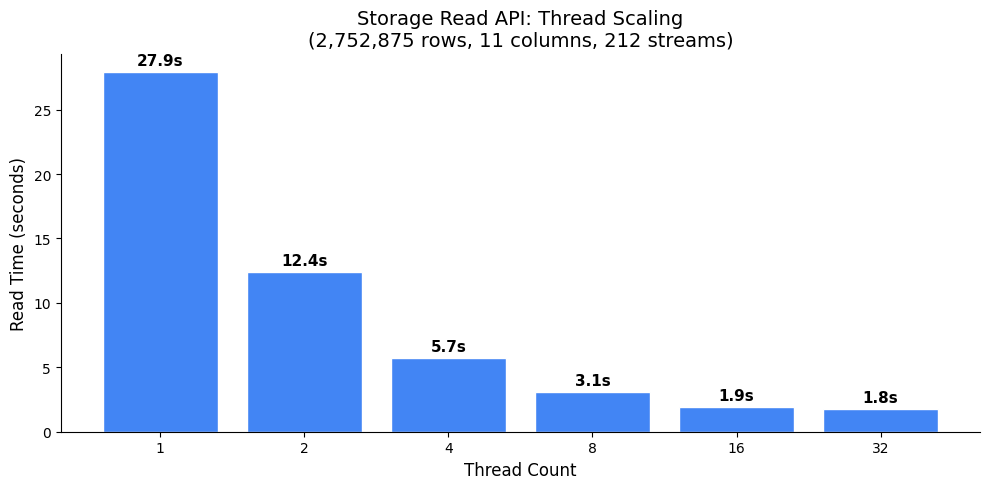

Speedup vs 1 thread:
   1 threads: 1.0x
   2 threads: 2.2x
   4 threads: 4.9x
   8 threads: 9.0x
  16 threads: 14.7x
  32 threads: 15.5x


In [31]:
# Plot: read time vs thread count
df_threads = pd.DataFrame(thread_timings)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    [str(t) for t in df_threads['threads']],
    df_threads['time_seconds'],
    color='#4285F4',
    edgecolor='white',
)

for bar, val in zip(bars, df_threads['time_seconds']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.1f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Thread Count', fontsize=12)
ax.set_ylabel('Read Time (seconds)', fontsize=12)
ax.set_title(
    f'Storage Read API: Thread Scaling\n'
    f'({df_threads["rows"].iloc[0]:,} rows, {len(NUMERIC_COLUMNS)} columns, '
    f'{df_threads["streams"].iloc[0]} streams)',
    fontsize=14,
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Show speedup relative to 1 thread
if len(df_threads) > 1:
    base = df_threads['time_seconds'].iloc[0]
    print('Speedup vs 1 thread:')
    for _, row in df_threads.iterrows():
        speedup = base / row['time_seconds'] if row['time_seconds'] > 0 else 0
        print(f'  {int(row["threads"]):>2d} threads: {speedup:.1f}x')

### Async Alternative: `asyncio.to_thread()`

Python's `asyncio` offers a modern alternative to `ThreadPoolExecutor` via `asyncio.to_thread()`. Since the BigQuery Storage client uses synchronous gRPC, `to_thread()` wraps each call in a thread — the same mechanism under the hood.

**Why only the Storage Read API?** Async/threading helps when you have **multiple independent operations** to parallelize. The Storage Read API is the only approach that exposes multiple streams — giving you something to run concurrently. The other approaches are single blocking calls:
- `client.query().to_dataframe()` — one download call (parallelism managed internally)
- `pandas_gbq.read_gbq()` — one blocking call (library manages streams)
- BigFrames `.to_pandas()` — one blocking call (BigFrames manages parallelism)
- `list_rows()` — sequential pagination (single stream by design)

Async *would* help for **concurrent multi-table reads** (e.g., reading 3 tables at once with `asyncio.gather()`), but that's application-level concurrency — not faster single-table reads.

In [ ]:
import asyncio

async def read_streams_async(streams, max_concurrent=16):
    """Read streams concurrently using asyncio with a concurrency limiter."""
    sem = asyncio.Semaphore(max_concurrent)

    async def read_one(stream):
        async with sem:
            return await asyncio.to_thread(read_stream, stream)

    return await asyncio.gather(*[read_one(s) for s in streams])

# Benchmark: asyncio with 16 concurrent reads
session = create_session(columns=NUMERIC_COLUMNS, row_filter=ROW_FILTER)

start = time.time()
dfs = await read_streams_async(session.streams, max_concurrent=16)
df = pd.concat(dfs, ignore_index=True)
elapsed = time.time() - start

print(f'asyncio (16 concurrent): {elapsed:.1f}s ({len(df):,} rows)')
print(f'ThreadPoolExecutor ({best["threads"]}):  {best["time_seconds"]}s')
print()
print('Performance is equivalent — asyncio.to_thread() uses a thread pool internally.')
print('Choose based on your application architecture, not raw speed.')

timings.append({'Approach': 'Storage API (asyncio)', 'Seconds': round(elapsed, 1), 'Rows': len(df)})

del df, dfs
_ = gc.collect()
print('Memory freed')

---
## Comparison Across Approaches

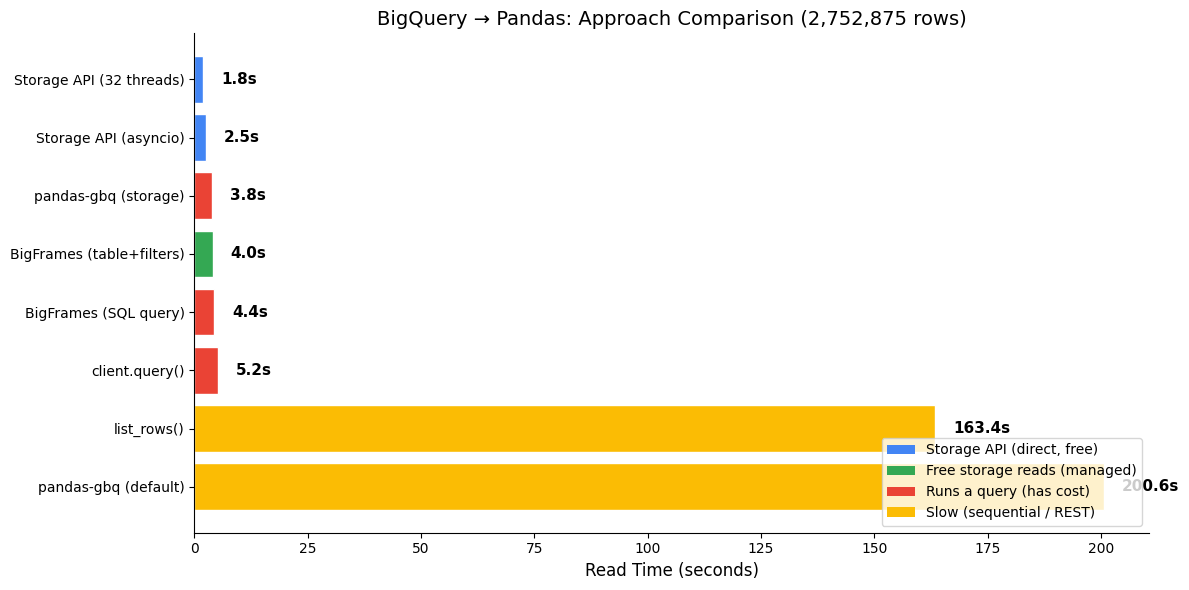

                 Approach  Seconds    Rows
 Storage API (32 threads)      1.8 2752875
    Storage API (asyncio)      2.5 2752875
     pandas-gbq (storage)      3.8 2752875
BigFrames (table+filters)      4.0 2752875
    BigFrames (SQL query)      4.4 2752875
           client.query()      5.2 2752875
              list_rows()    163.4 2752875
     pandas-gbq (default)    200.6 2752875


In [33]:
# Build comparison table, sorted by time
df_timings = pd.DataFrame(timings).sort_values('Seconds').reset_index(drop=True)

# Color by cost/speed category
def get_color(approach):
    a = approach.lower()
    if 'storage api' in a:
        return '#4285F4'  # blue — direct storage API, free, controllable
    elif 'table+filters' in a:
        return '#34A853'  # green — free managed storage reads
    elif 'list' in a or 'default' in a:
        return '#FBBC04'  # yellow — slow (sequential / REST)
    else:
        return '#EA4335'  # red — runs a query (has cost)

colors = [get_color(a) for a in df_timings['Approach']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(df_timings['Approach'], df_timings['Seconds'], color=colors, edgecolor='white')

for bar, val in zip(bars, df_timings['Seconds']):
    label_x = bar.get_width() + max(df_timings['Seconds']) * 0.02
    ax.text(label_x, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}s', ha='left', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Read Time (seconds)', fontsize=12)
ax.set_title(f'BigQuery → Pandas: Approach Comparison ({EXPECTED_ROWS:,} rows)', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.invert_yaxis()

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4285F4', label='Storage API (direct, free)'),
    Patch(facecolor='#34A853', label='Free storage reads (managed)'),
    Patch(facecolor='#EA4335', label='Runs a query (has cost)'),
    Patch(facecolor='#FBBC04', label='Slow (sequential / REST)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

# Print the table
print(df_timings.to_string(index=False))

---
## Alternatives for ML Frameworks

All major ML frameworks consume data through **pandas**, **numpy**, or **Arrow** as intermediaries:

| Framework | BigQuery → Framework Path |
|---|---|
| **scikit-learn** | BigQuery → pandas → numpy (automatic) |
| **PyTorch** | BigQuery → pandas → `torch.from_numpy(df.values)` or `torch.tensor()` |
| **JAX** | BigQuery → pandas → `jax.numpy.array(df.values)` |
| **Keras** (any backend) | BigQuery → pandas → framework-specific tensors |
| **TensorFlow** | BigQuery → `tensorflow_io.bigquery.BigQueryClient` (native, parallel reads into `tf.data.Dataset`) |

TensorFlow I/O's `BigQueryClient` is the one framework with direct BigQuery integration, supporting parallel read sessions.

For all other frameworks, **efficient BigQuery → pandas reads are the foundation**.

---
## Summary

### Recommendations

| Need | Use | Cost |
|---|---|---|
| Quick exploration, small data | `client.query()` | Query cost |
| Simple storage read, no filtering | `client.list_rows()` | Storage reads* |
| Minimal code, fast download | `pandas_gbq.read_gbq(use_bqstorage_api=True)` | Query cost |
| Easy storage reads, no query cost | BigFrames `read_gbq_table(columns=..., filters=...)` | Storage reads* |
| Maximum speed, full control | Storage Read API + `ThreadPoolExecutor` | Storage reads* |
| Async application architecture | Storage Read API + `asyncio.to_thread()` | Storage reads* |

*\*Storage reads: free up to 300 TiB/month per billing account, then $1.10/TiB.*

### Key Takeaways

1. **Avoid unnecessary query costs** — if you're reading a table (not computing a join or aggregation), use storage reads via BigFrames `read_gbq_table()` or the Storage Read API directly.
2. **`use_bqstorage_api=True` is essential for pandas-gbq** — without it, downloads are 50x slower. The speed difference is in the download, not the query.
3. **`client.query().to_dataframe()` is faster than you'd expect** — it already uses the Storage API for downloads when the package is installed.
4. **Storage Read API gives maximum control** — you choose the thread count. Since reads are I/O-bound, more threads than CPUs can help significantly — see the thread scaling chart above.
5. **BigFrames `read_gbq_table` is the easy zero-cost path** — storage reads, column pruning, and row filtering with `partial` ordering mode, all managed for you. Competitive speed with query-based approaches, and effectively free for most workloads.
6. **`asyncio` doesn't improve raw speed** — `asyncio.to_thread()` uses a thread pool internally, so performance matches `ThreadPoolExecutor`. Choose based on your application architecture (event loop vs thread pool), not raw throughput.
7. **Column pruning matters** — reading 11 of 23 columns saved 77% of the data scanned.
8. **Memory safety first** — always estimate `rows * columns * 8 bytes` before downloading. Use `to_pandas_batches()` or row filters for large tables.
9. **`list_rows()` and pandas-gbq default are very slow** — sequential pagination can't compete with parallel storage reads.